# Export Funafuti Threshold GeoJSON

This notebook converts the five DEM threshold masks into GeoJSON for the
MapLibre map.

The exported classes are `land` and `flooded`. The `flooded` class name is
kept for the web layer, but it means DEM land at or below the selected
threshold; it is not a hydrodynamic flood extent.

## 1. Setup

In [1]:
import numpy as np
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape, mapping
from shapely.ops import unary_union
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Portable project root: works when Jupyter is launched from the repo root
# or from the notebooks/ directory. No machine-specific absolute paths.
PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DEM_PATH = PROJECT_ROOT / "data" / "raw" / "tuvalu_dem_funafuti_admin.tif"
OUTPUT_DIR = PROJECT_ROOT / "output" / "geojson"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DEM path:", DEM_PATH, "exists:", DEM_PATH.exists())

# Illustrative relative sea-level increments (metres).
# These thresholds are not assigned to specific future years.
SCENARIOS = [
    {"key": "s0", "label": "Baseline (0.0m)", "rise_m": 0.0},
    {"key": "s05", "label": "+0.5m", "rise_m": 0.5},
    {"key": "s10", "label": "+1.0m", "rise_m": 1.0},
    {"key": "s15", "label": "+1.5m", "rise_m": 1.5},
    {"key": "s20", "label": "+2.0m", "rise_m": 2.0},
]


SIMPLIFY_TOLERANCE_M = 5.0
AREA_QC_TOLERANCE_PCT = 3.0

DEM path: ..\data\raw\tuvalu_dem_funafuti_admin.tif exists: True


## 2. Vectorisation

Raster masks are merged in the DEM's projected CRS, simplified with a small
metric tolerance, and then transformed to EPSG:4326 for web mapping.

The simplification tolerance is kept well below the DEM pixel size. A separate
area check compares each exported geometry with its source raster mask.

In [2]:
from pyproj import Transformer
from shapely.ops import transform as shapely_transform

def vectorize(mask, transform_affine, src_crs, value_label, simplify_tol_m=SIMPLIFY_TOLERANCE_M):
    geoms = [
        shape(geom)
        for geom, val in shapes(
            mask.astype(np.uint8),
            mask=mask,
            transform=transform_affine,
        )
    ]
    if not geoms:
        return {"type": "FeatureCollection", "features": []}

    merged = unary_union(geoms)
    if simplify_tol_m > 0:
        merged = merged.simplify(simplify_tol_m, preserve_topology=True)

    to_wgs84 = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True).transform
    merged_wgs84 = shapely_transform(to_wgs84, merged)

    return {
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature",
            "properties": {"class": value_label},
            "geometry": mapping(merged_wgs84),
        }],
    }


def feature_collection_area_km2(feature_collection, target_crs):
    if not feature_collection["features"]:
        return 0.0

    to_target = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True).transform
    total_m2 = 0.0
    for feature in feature_collection["features"]:
        geom = shape(feature["geometry"])
        total_m2 += shapely_transform(to_target, geom).area
    return total_m2 / 1e6

## 3. Load DEM

In [3]:
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1)
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

baseline_land = (dem > 0) & (dem != nodata)
print(f"CRS: {crs}, shape: {dem.shape}, baseline land pixels: {baseline_land.sum():,}")

if crs is None or not crs.is_projected:
    raise ValueError("The DEM must use a projected CRS for raster/vector area QA.")

pixel_area_m2 = abs(transform.a * transform.e)

CRS: EPSG:3832, shape: (3554, 3939), baseline land pixels: 3,687


## 4. Export scenarios

Each threshold produces two geometries:

- `land`: baseline land above the threshold
- `flooded`: baseline land at or below the threshold

Raster and vector areas are compared after export. The notebook stops if the
difference exceeds the QA tolerance.

In [4]:
feature_counts = []
area_qc = []

for scenario in SCENARIOS:
    rise = scenario["rise_m"]
    remaining_land = baseline_land & (dem > rise)
    flooded = baseline_land & (dem <= rise)

    land_fc = vectorize(
        remaining_land, transform, crs, "land",
        simplify_tol_m=SIMPLIFY_TOLERANCE_M,
    )
    flood_fc = vectorize(
        flooded, transform, crs, "flooded",
        simplify_tol_m=SIMPLIFY_TOLERANCE_M,
    )

    out_path = OUTPUT_DIR / f"{scenario['key']}.geojson"
    combined = {
        "type": "FeatureCollection",
        "features": land_fc["features"] + flood_fc["features"],
        "meta": {
            "label": scenario["label"],
            "rise_m": rise,
            "simplify_tolerance_m": SIMPLIFY_TOLERANCE_M,
        },
    }
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(combined, f)

    feature_counts.append(
        (scenario["label"], len(land_fc["features"]), len(flood_fc["features"]))
    )

    for class_name, mask, fc in [
        ("land", remaining_land, land_fc),
        ("flooded", flooded, flood_fc),
    ]:
        raster_area_km2 = float(mask.sum() * pixel_area_m2 / 1e6)
        vector_area_km2 = feature_collection_area_km2(fc, crs)

        if raster_area_km2 == 0:
            diff_pct = 0.0 if vector_area_km2 < 1e-9 else float("inf")
        else:
            diff_pct = abs(vector_area_km2 - raster_area_km2) / raster_area_km2 * 100

        area_qc.append({
            "scenario": scenario["label"],
            "class": class_name,
            "raster_area_km2": raster_area_km2,
            "vector_area_km2": vector_area_km2,
            "difference_pct": diff_pct,
        })

    print(
        f"{scenario['label']:15s} -> "
        f"{len(land_fc['features'])} land feature(s), "
        f"{len(flood_fc['features'])} threshold feature(s) -> {out_path}"
    )

print("\nRaster/vector area check")
for row in area_qc:
    diff = row["difference_pct"]
    status = "PASS" if diff <= AREA_QC_TOLERANCE_PCT else "FAIL"
    print(
        f"{status:4s}  {row['scenario']:15s} {row['class']:7s} "
        f"raster={row['raster_area_km2']:.4f} km2  "
        f"vector={row['vector_area_km2']:.4f} km2  "
        f"diff={diff:.2f}%"
    )

failed_area_checks = [
    row for row in area_qc
    if row["difference_pct"] > AREA_QC_TOLERANCE_PCT
]
if failed_area_checks:
    raise RuntimeError(
        "GeoJSON area differs from the raster mask by more than "
        f"{AREA_QC_TOLERANCE_PCT:.1f}%. Reduce SIMPLIFY_TOLERANCE_M and rerun."
    )

Baseline (0.0m) -> 1 land feature(s), 0 threshold feature(s) -> ..\output\geojson\s0.geojson


+0.5m           -> 1 land feature(s), 0 threshold feature(s) -> ..\output\geojson\s05.geojson


+1.0m           -> 1 land feature(s), 1 threshold feature(s) -> ..\output\geojson\s10.geojson


+1.5m           -> 1 land feature(s), 1 threshold feature(s) -> ..\output\geojson\s15.geojson


+2.0m           -> 1 land feature(s), 1 threshold feature(s) -> ..\output\geojson\s20.geojson

Raster/vector area check
PASS  Baseline (0.0m) land    raster=3.5020 km2  vector=3.5020 km2  diff=0.00%
PASS  Baseline (0.0m) flooded raster=0.0000 km2  vector=0.0000 km2  diff=0.00%
PASS  +0.5m           land    raster=3.5020 km2  vector=3.5020 km2  diff=0.00%
PASS  +0.5m           flooded raster=0.0000 km2  vector=0.0000 km2  diff=0.00%
PASS  +1.0m           land    raster=2.9606 km2  vector=2.9606 km2  diff=0.00%
PASS  +1.0m           flooded raster=0.5414 km2  vector=0.5414 km2  diff=0.00%
PASS  +1.5m           land    raster=2.9606 km2  vector=2.9606 km2  diff=0.00%
PASS  +1.5m           flooded raster=0.5414 km2  vector=0.5414 km2  diff=0.00%
PASS  +2.0m           land    raster=2.5332 km2  vector=2.5332 km2  diff=0.00%
PASS  +2.0m           flooded raster=0.9688 km2  vector=0.9688 km2  diff=0.00%


## 5. Combined web file

In [5]:
combined = {}
for scenario in SCENARIOS:
    with open(OUTPUT_DIR / f"{scenario['key']}.geojson", encoding="utf-8") as f:
        combined[scenario["key"]] = json.load(f)

combined_path = OUTPUT_DIR / "combined.json"
with open(combined_path, "w", encoding="utf-8") as f:
    json.dump(combined, f)

print(f"Combined all scenarios -> {combined_path}")
print(f"Combined file size: {combined_path.stat().st_size / 1024:.1f} KB")

Combined all scenarios -> ..\output\geojson\combined.json
Combined file size: 357.1 KB


## 6. Visual check

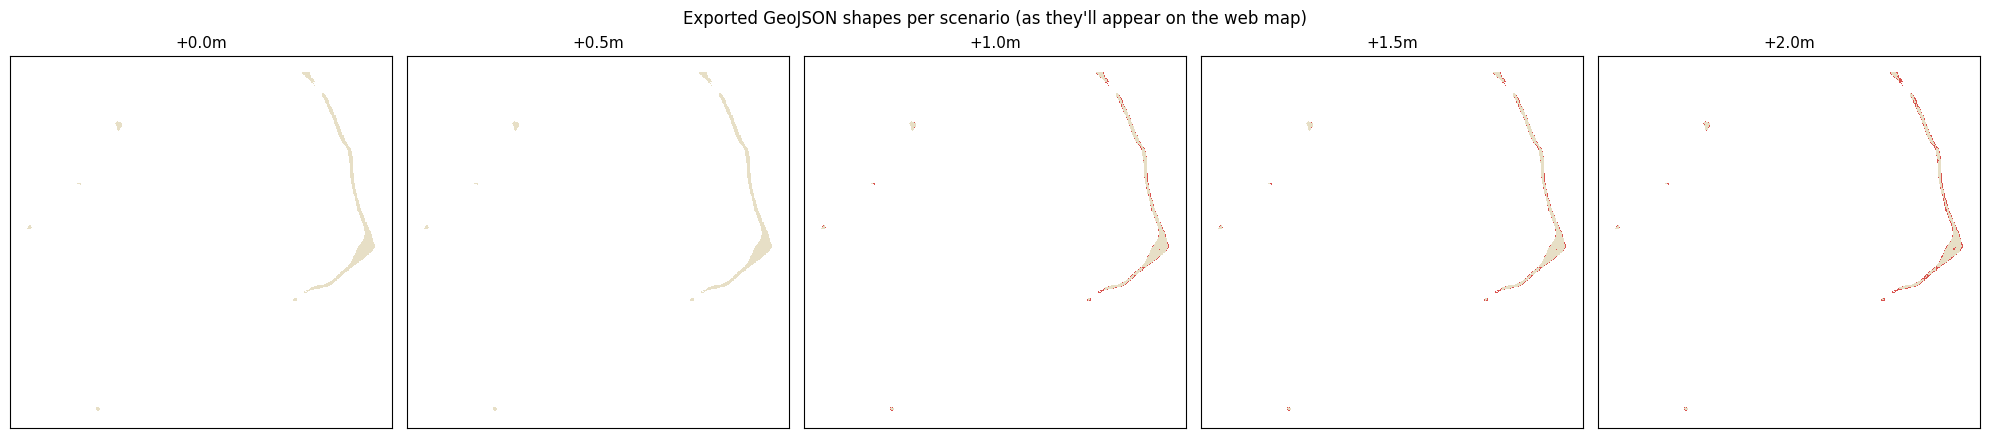

In [6]:
import geopandas as gpd

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(4 * len(SCENARIOS), 4.5))
for ax, scenario in zip(axes, SCENARIOS):
    with open(OUTPUT_DIR / f"{scenario['key']}.geojson", encoding="utf-8") as f:
        gj = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(gj["features"], crs="EPSG:4326")
    if len(gdf):
        land_subset = gdf[gdf["class"] == "land"]
        flood_subset = gdf[gdf["class"] == "flooded"]
        if len(land_subset):
            land_subset.plot(ax=ax, color="#E7DFC6")
        if len(flood_subset):
            flood_subset.plot(ax=ax, color="#D9534F")
    ax.set_title(f"+{scenario['rise_m']}m", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Exported GeoJSON shapes per scenario (as they'll appear on the web map)")
plt.tight_layout()
plt.show()

## 7. Build sequence

After the GeoJSON is written, run `04_sea_level_trend.ipynb` and
`05_build_html.ipynb`.